═══════════════════════════════════════════════════════════════════════════
📌 Notebook 4: Determinação do Número Ideal de Clusters
═══════════════════════════════════════════════════════════════════════════

Neste notebook vamos:
✅ Aplicar o Método do Cotovelo (Elbow Method)
✅ Calcular Silhouette Score
✅ Calcular Davies-Bouldin Index
✅ Calcular Calinski-Harabasz Score
✅ Analisar múltiplas métricas
✅ Decidir o número ideal de clusters (K)

⏱️ Tempo estimado: 25-35 minutos

💡 CONCEITOS IMPORTANTES:

K ideal é aquele que:
- Maximiza a separação entre clusters
- Minimiza a variação dentro de cada cluster
- Tem sentido prático/interpretável

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 1: Setup
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("🎯 DETERMINAÇÃO DO NÚMERO IDEAL DE CLUSTERS")
print("="*80)
print("✅ Bibliotecas carregadas!")
print()

🎯 DETERMINAÇÃO DO NÚMERO IDEAL DE CLUSTERS
✅ Bibliotecas carregadas!



In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 2: Carregar dados processados
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import json
import pandas as pd

print("="*80)
print("📂 CARREGANDO DADOS PROCESSADOS")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Paths
data_path = base_path / 'data/processed/municipios_preprocessed.csv'
features_path = base_path / 'outputs/results/features_selecionadas.json'

# Carregar dataset completo
if not data_path.exists():
    raise FileNotFoundError(f"❌ Arquivo não encontrado: {data_path}")

df = pd.read_csv(data_path)
print(f"✅ Dataset carregado: {len(df):,} municípios")

# Carregar lista de features
if not features_path.exists():
    raise FileNotFoundError(f"❌ Arquivo não encontrado: {features_path}")

with open(features_path, 'r', encoding='utf-8') as f:
    features_metadata = json.load(f)
    selected_features = features_metadata['features_selecionadas']

print(f"✅ Features carregadas: {len(selected_features)}")
print()
print("📋 Features para clustering:")
for i, feat in enumerate(selected_features, 1):
    print(f"   {i}. {feat}")

# Extrair matriz de features (X)
X = df[selected_features].values

print()
print(f"📊 Matriz X: {X.shape[0]:,} amostras × {X.shape[1]} features")
print()


📂 CARREGANDO DADOS PROCESSADOS

✅ Dataset carregado: 5,204 municípios
✅ Features carregadas: 7

📋 Features para clustering:
   1. log_populacao
   2. log_densidade
   3. pib_per_capita
   4. taxa_alfabetizacao
   5. mortalidade_infantil
   6. esgoto_adequado
   7. saude_per_10k

📊 Matriz X: 5,204 amostras × 7 features



In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 3: Método do Cotovelo (Elbow Method)
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("📈 MÉTODO DO COTOVELO (ELBOW METHOD)")
print("="*80)
print()

print("💡 O QUE É?")
print()
print("   O Método do Cotovelo analisa a INÉRCIA (soma das distâncias")
print("   quadradas dos pontos aos seus centróides).")
print()
print("   • Quanto menor a inércia, mais coesos os clusters")
print("   • Adicionar mais clusters sempre reduz a inércia")
print("   • O 'cotovelo' é onde a redução desacelera")
print()
print("   Fórmula da inércia:")
print("   WCSS = Σ Σ ||xᵢ - μⱼ||²")
print("   (soma das distâncias de cada ponto ao seu centróide)")
print()

# Testar diferentes valores de K
k_range = range(2, 11)  # Testar de 2 a 10 clusters
inertias = []
execution_times = []

print("🔄 Testando diferentes valores de K...")
print()

for k in k_range:
    print(f"   K = {k}...", end=" ")
    start_time = time.time()
    
    # Treinar KMeans
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    kmeans.fit(X)
    
    # Armazenar inércia
    inertia = kmeans.inertia_
    inertias.append(inertia)
    
    # Tempo de execução
    exec_time = time.time() - start_time
    execution_times.append(exec_time)
    
    print(f"Inércia: {inertia:,.2f} | Tempo: {exec_time:.2f}s")

print()
print("✅ Método do Cotovelo executado!")

# Criar DataFrame com resultados
elbow_df = pd.DataFrame({
    'K': list(k_range),
    'Inertia': inertias,
    'Tempo_segundos': execution_times
})

print()
print("📊 RESULTADOS:")
display(elbow_df)

# Calcular taxa de redução da inércia
elbow_df['Reducao_%'] = elbow_df['Inertia'].pct_change() * -100
print()
print("📉 TAXA DE REDUÇÃO DA INÉRCIA:")
print("   (Quanto a inércia diminui ao adicionar mais um cluster)")
print()
display(elbow_df[['K', 'Inertia', 'Reducao_%']])

📈 MÉTODO DO COTOVELO (ELBOW METHOD)

💡 O QUE É?

   O Método do Cotovelo analisa a INÉRCIA (soma das distâncias
   quadradas dos pontos aos seus centróides).

   • Quanto menor a inércia, mais coesos os clusters
   • Adicionar mais clusters sempre reduz a inércia
   • O 'cotovelo' é onde a redução desacelera

   Fórmula da inércia:
   WCSS = Σ Σ ||xᵢ - μⱼ||²
   (soma das distâncias de cada ponto ao seu centróide)

🔄 Testando diferentes valores de K...

   K = 2... Inércia: 30,383.69 | Tempo: 2.12s
   K = 3... Inércia: 27,253.29 | Tempo: 0.14s
   K = 4... Inércia: 24,805.55 | Tempo: 0.11s
   K = 5... Inércia: 22,631.02 | Tempo: 0.15s
   K = 6... Inércia: 21,144.88 | Tempo: 0.19s
   K = 7... Inércia: 19,911.19 | Tempo: 0.21s
   K = 8... Inércia: 19,121.05 | Tempo: 0.17s
   K = 9... Inércia: 18,449.42 | Tempo: 0.20s
   K = 10... Inércia: 17,809.43 | Tempo: 0.21s

✅ Método do Cotovelo executado!

📊 RESULTADOS:


,K,Inertia,Tempo_segundos
0,2,30383.692038,2.115069
1,3,27253.290986,0.143104
2,4,24805.545481,0.108449
3,5,22631.021878,0.150013
4,6,21144.876261,0.186106
5,7,19911.191426,0.209129
6,8,19121.045437,0.169788
7,9,18449.422529,0.195534
8,10,17809.425677,0.213484



📉 TAXA DE REDUÇÃO DA INÉRCIA:
   (Quanto a inércia diminui ao adicionar mais um cluster)



,K,Inertia,Reducao_%
0,2,30383.692038,NaN
1,3,27253.290986,10.302899
2,4,24805.545481,8.981468
3,5,22631.021878,8.766280
4,6,21144.876261,6.566852
5,7,19911.191426,5.834439
6,8,19121.045437,3.968351
7,9,18449.422529,3.512480
8,10,17809.425677,3.468926



📊 VISUALIZAÇÃO DO MÉTODO DO COTOVELO

✅ Gráfico salvo: ..\outputs\figures\10_metodo_cotovelo.png


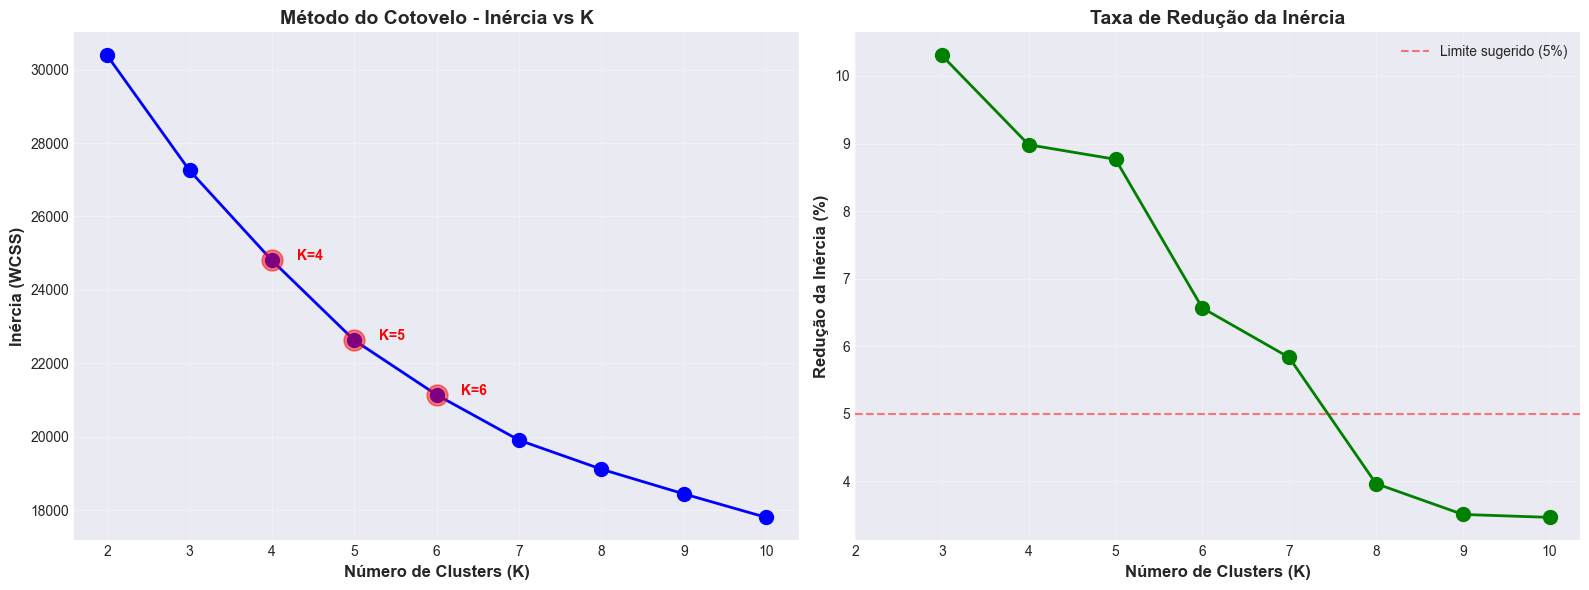

✅ Gráfico interativo salvo: ..\outputs\figures\11_elbow_interativo.html



💡 INTERPRETAÇÃO DO COTOVELO:

   Procuramos o ponto onde a curva 'dobra' (cotovelo).
   Antes do cotovelo: grande ganho ao adicionar clusters
   Depois do cotovelo: ganho marginal diminui

   📌 Neste caso, o cotovelo parece estar em K = 4, 5 ou 6



In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 4: Visualizar Método do Cotovelo
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import matplotlib.pyplot as plt
import plotly.graph_objects as go

print("\n" + "="*80)
print("📊 VISUALIZAÇÃO DO MÉTODO DO COTOVELO")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Diretório de saída das figuras
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------------
# Gráfico 1: Matplotlib (estático)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Inércia vs K
axes[0].plot(elbow_df['K'], elbow_df['Inertia'], 'bo-', linewidth=2, markersize=10)
axes[0].set_xlabel('Número de Clusters (K)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Inércia (WCSS)', fontsize=12, fontweight='bold')
axes[0].set_title('Método do Cotovelo - Inércia vs K', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(elbow_df['K'])

# Marcar possíveis cotovelos (K=4, K=5, K=6)
for k in [4, 5, 6]:
    if k in elbow_df['K'].values:
        idx = elbow_df[elbow_df['K'] == k].index[0]
        axes[0].plot(k, elbow_df.loc[idx, 'Inertia'], 'ro', markersize=15, alpha=0.5)
        axes[0].annotate(
            f'K={k}',
            xy=(k, elbow_df.loc[idx, 'Inertia']),
            xytext=(k + 0.3, elbow_df.loc[idx, 'Inertia']),
            fontsize=10, fontweight='bold', color='red'
        )

# Taxa de redução
axes[1].plot(elbow_df['K'][1:], elbow_df['Reducao_%'][1:], 'go-', linewidth=2, markersize=10)
axes[1].set_xlabel('Número de Clusters (K)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Redução da Inércia (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Taxa de Redução da Inércia', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(elbow_df['K'])
axes[1].axhline(y=5, color='r', linestyle='--', alpha=0.5, label='Limite sugerido (5%)')
axes[1].legend()

plt.tight_layout()

output_png = output_dir / '10_metodo_cotovelo.png'
plt.savefig(output_png, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico salvo: {output_png}")
plt.show()

# -------------------------------------------------------------------------
# Gráfico 2: Plotly (interativo)
# -------------------------------------------------------------------------
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=elbow_df['K'],
    y=elbow_df['Inertia'],
    mode='lines+markers',
    name='Inércia',
    line=dict(color='#FF6B6B', width=3),
    marker=dict(size=12, color='#FF6B6B', line=dict(width=2, color='white')),
    hovertemplate='<b>K=%{x}</b><br>Inércia: %{y:,.2f}<extra></extra>'
))

# Destacar K=5
if 5 in elbow_df['K'].values:
    k5_idx = elbow_df[elbow_df['K'] == 5].index[0]
    fig.add_trace(go.Scatter(
        x=[5],
        y=[elbow_df.loc[k5_idx, 'Inertia']],
        mode='markers',
        name='K=5 (sugerido)',
        marker=dict(size=20, color='yellow', symbol='star',
                    line=dict(width=2, color='red'))
    ))

fig.update_layout(
    title='Método do Cotovelo - Inércia vs Número de Clusters',
    xaxis_title='Número de Clusters (K)',
    yaxis_title='Inércia (WCSS)',
    template='plotly_white',
    height=600,
    hovermode='x unified',
    font=dict(size=12)
)

output_html = output_dir / '11_elbow_interativo.html'
fig.write_html(output_html)
print(f"✅ Gráfico interativo salvo: {output_html}")
fig.show()

print()
print("💡 INTERPRETAÇÃO DO COTOVELO:")
print()
print("   Procuramos o ponto onde a curva 'dobra' (cotovelo).")
print("   Antes do cotovelo: grande ganho ao adicionar clusters")
print("   Depois do cotovelo: ganho marginal diminui")
print()
print("   📌 Neste caso, o cotovelo parece estar em K = 4, 5 ou 6")
print()


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 5: Silhouette Score
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🎯 SILHOUETTE SCORE")
print("="*80)
print()

print("💡 O QUE É?")
print()
print("   O Silhouette Score mede quão bem cada ponto está")
print("   agrupado em seu cluster comparado aos outros clusters.")
print()
print("   Para cada ponto i:")
print("   • a(i) = distância média para pontos do MESMO cluster")
print("   • b(i) = distância média para pontos do cluster MAIS PRÓXIMO")
print()
print("   Silhouette(i) = [b(i) - a(i)] / max(a(i), b(i))")
print()
print("   Valores:")
print("   • +1: Ponto muito bem agrupado")
print("   •  0: Ponto na fronteira entre clusters")
print("   • -1: Ponto provavelmente no cluster errado")
print()
print("   Score médio > 0.5 é considerado bom")
print("   Score médio > 0.7 é excelente")
print()

# Calcular Silhouette Score para diferentes K
silhouette_scores = []

print("🔄 Calculando Silhouette Score para cada K...")
print()

for k in k_range:
    print(f"   K = {k}...", end=" ")
    
    # Treinar KMeans
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X)
    
    # Calcular Silhouette Score
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    
    print(f"Silhouette: {score:.4f}")

print()
print("✅ Silhouette Score calculado!")

# Adicionar ao DataFrame
elbow_df['Silhouette'] = silhouette_scores

print()
print("📊 RESULTADOS CONSOLIDADOS:")
display(elbow_df[['K', 'Inertia', 'Silhouette']])

🎯 SILHOUETTE SCORE

💡 O QUE É?

   O Silhouette Score mede quão bem cada ponto está
   agrupado em seu cluster comparado aos outros clusters.

   Para cada ponto i:
   • a(i) = distância média para pontos do MESMO cluster
   • b(i) = distância média para pontos do cluster MAIS PRÓXIMO

   Silhouette(i) = [b(i) - a(i)] / max(a(i), b(i))

   Valores:
   • +1: Ponto muito bem agrupado
   •  0: Ponto na fronteira entre clusters
   • -1: Ponto provavelmente no cluster errado

   Score médio > 0.5 é considerado bom
   Score médio > 0.7 é excelente

🔄 Calculando Silhouette Score para cada K...

   K = 2... Silhouette: 0.1550
   K = 3... Silhouette: 0.1444
   K = 4... Silhouette: 0.1516
   K = 5... Silhouette: 0.1392
   K = 6... Silhouette: 0.1339
   K = 7... Silhouette: 0.1340
   K = 8... Silhouette: 0.1266
   K = 9... Silhouette: 0.1234
   K = 10... Silhouette: 0.1227

✅ Silhouette Score calculado!

📊 RESULTADOS CONSOLIDADOS:


,K,Inertia,Silhouette
0,2,30383.692038,0.154965
1,3,27253.290986,0.144392
2,4,24805.545481,0.151609
3,5,22631.021878,0.139192
4,6,21144.876261,0.133899
5,7,19911.191426,0.134043
6,8,19121.045437,0.126647
7,9,18449.422529,0.123383
8,10,17809.425677,0.122674


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 6: Davies-Bouldin Index
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📐 DAVIES-BOULDIN INDEX")
print("="*80)
print()

print("💡 O QUE É?")
print()
print("   O Davies-Bouldin Index mede a separação entre clusters.")
print()
print("   Para cada cluster:")
print("   • Calcula dispersão interna (quão espalhado)")
print("   • Calcula distância para outros clusters")
print()
print("   DB = (1/K) × Σ max[(sᵢ + sⱼ) / dᵢⱼ]")
print()
print("   Onde:")
print("   • sᵢ = dispersão do cluster i")
print("   • dᵢⱼ = distância entre centróides i e j")
print()
print("   Valores:")
print("   • MENOR é MELHOR")
print("   • Próximo de 0 = clusters bem separados")
print("   • Valores altos = clusters sobrepostos")
print()

# Calcular Davies-Bouldin Index
db_scores = []

print("🔄 Calculando Davies-Bouldin Index para cada K...")
print()

for k in k_range:
    print(f"   K = {k}...", end=" ")
    
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X)
    
    score = davies_bouldin_score(X, labels)
    db_scores.append(score)
    
    print(f"DB Index: {score:.4f}")

print()
print("✅ Davies-Bouldin Index calculado!")

# Adicionar ao DataFrame
elbow_df['Davies_Bouldin'] = db_scores


📐 DAVIES-BOULDIN INDEX

💡 O QUE É?

   O Davies-Bouldin Index mede a separação entre clusters.

   Para cada cluster:
   • Calcula dispersão interna (quão espalhado)
   • Calcula distância para outros clusters

   DB = (1/K) × Σ max[(sᵢ + sⱼ) / dᵢⱼ]

   Onde:
   • sᵢ = dispersão do cluster i
   • dᵢⱼ = distância entre centróides i e j

   Valores:
   • MENOR é MELHOR
   • Próximo de 0 = clusters bem separados
   • Valores altos = clusters sobrepostos

🔄 Calculando Davies-Bouldin Index para cada K...

   K = 2... DB Index: 2.1054
   K = 3... DB Index: 2.0201
   K = 4... DB Index: 1.7918
   K = 5... DB Index: 1.7644
   K = 6... DB Index: 1.6630
   K = 7... DB Index: 1.5778
   K = 8... DB Index: 1.6363
   K = 9... DB Index: 1.6403
   K = 10... DB Index: 1.5863

✅ Davies-Bouldin Index calculado!


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 7: Calinski-Harabasz Score
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📊 CALINSKI-HARABASZ SCORE (Variance Ratio)")
print("="*80)
print()

print("💡 O QUE É?")
print()
print("   Também conhecido como Variance Ratio Criterion.")
print("   Mede a razão entre dispersão ENTRE clusters e")
print("   dispersão DENTRO dos clusters.")
print()
print("   CH = [SSB / (K-1)] / [SSW / (N-K)]")
print()
print("   Onde:")
print("   • SSB = Sum of Squares Between clusters")
print("   • SSW = Sum of Squares Within clusters")
print("   • K = número de clusters")
print("   • N = número de pontos")
print()
print("   Valores:")
print("   • MAIOR é MELHOR")
print("   • Valores altos = clusters bem definidos e separados")
print()

# Calcular Calinski-Harabasz Score
ch_scores = []

print("🔄 Calculando Calinski-Harabasz Score para cada K...")
print()

for k in k_range:
    print(f"   K = {k}...", end=" ")
    
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X)
    
    score = calinski_harabasz_score(X, labels)
    ch_scores.append(score)
    
    print(f"CH Score: {score:.2f}")

print()
print("✅ Calinski-Harabasz Score calculado!")

# Adicionar ao DataFrame
elbow_df['Calinski_Harabasz'] = ch_scores

print()
print("📊 TABELA COMPLETA DE MÉTRICAS:")
display(elbow_df)


📊 CALINSKI-HARABASZ SCORE (Variance Ratio)

💡 O QUE É?

   Também conhecido como Variance Ratio Criterion.
   Mede a razão entre dispersão ENTRE clusters e
   dispersão DENTRO dos clusters.

   CH = [SSB / (K-1)] / [SSW / (N-K)]

   Onde:
   • SSB = Sum of Squares Between clusters
   • SSW = Sum of Squares Within clusters
   • K = número de clusters
   • N = número de pontos

   Valores:
   • MAIOR é MELHOR
   • Valores altos = clusters bem definidos e separados

🔄 Calculando Calinski-Harabasz Score para cada K...

   K = 2... CH Score: 1034.86
   K = 3... CH Score: 875.45
   K = 4... CH Score: 812.15
   K = 5... CH Score: 792.39
   K = 6... CH Score: 751.41
   K = 7... CH Score: 718.51
   K = 8... CH Score: 671.86
   K = 9... CH Score: 632.80
   K = 10... CH Score: 603.33

✅ Calinski-Harabasz Score calculado!

📊 TABELA COMPLETA DE MÉTRICAS:


,K,Inertia,Tempo_segundos,Reducao_%,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,30383.692038,2.115069,NaN,0.154965,2.105382,1034.860339
1,3,27253.290986,0.143104,10.302899,0.144392,2.020103,875.447696
2,4,24805.545481,0.108449,8.981468,0.151609,1.791820,812.147822
3,5,22631.021878,0.150013,8.766280,0.139192,1.764423,792.393161
4,6,21144.876261,0.186106,6.566852,0.133899,1.663026,751.408846
5,7,19911.191426,0.209129,5.834439,0.134043,1.577836,718.512243
6,8,19121.045437,0.169788,3.968351,0.126647,1.636337,671.862383
7,9,18449.422529,0.195534,3.512480,0.123383,1.640320,632.803768
8,10,17809.425677,0.213484,3.468926,0.122674,1.586277,603.331987



📈 COMPARAÇÃO DE TODAS AS MÉTRICAS

✅ Gráfico interativo salvo: ..\outputs\figures\12_metricas_comparacao.html


✅ Gráfico salvo: ..\outputs\figures\13_todas_metricas.png


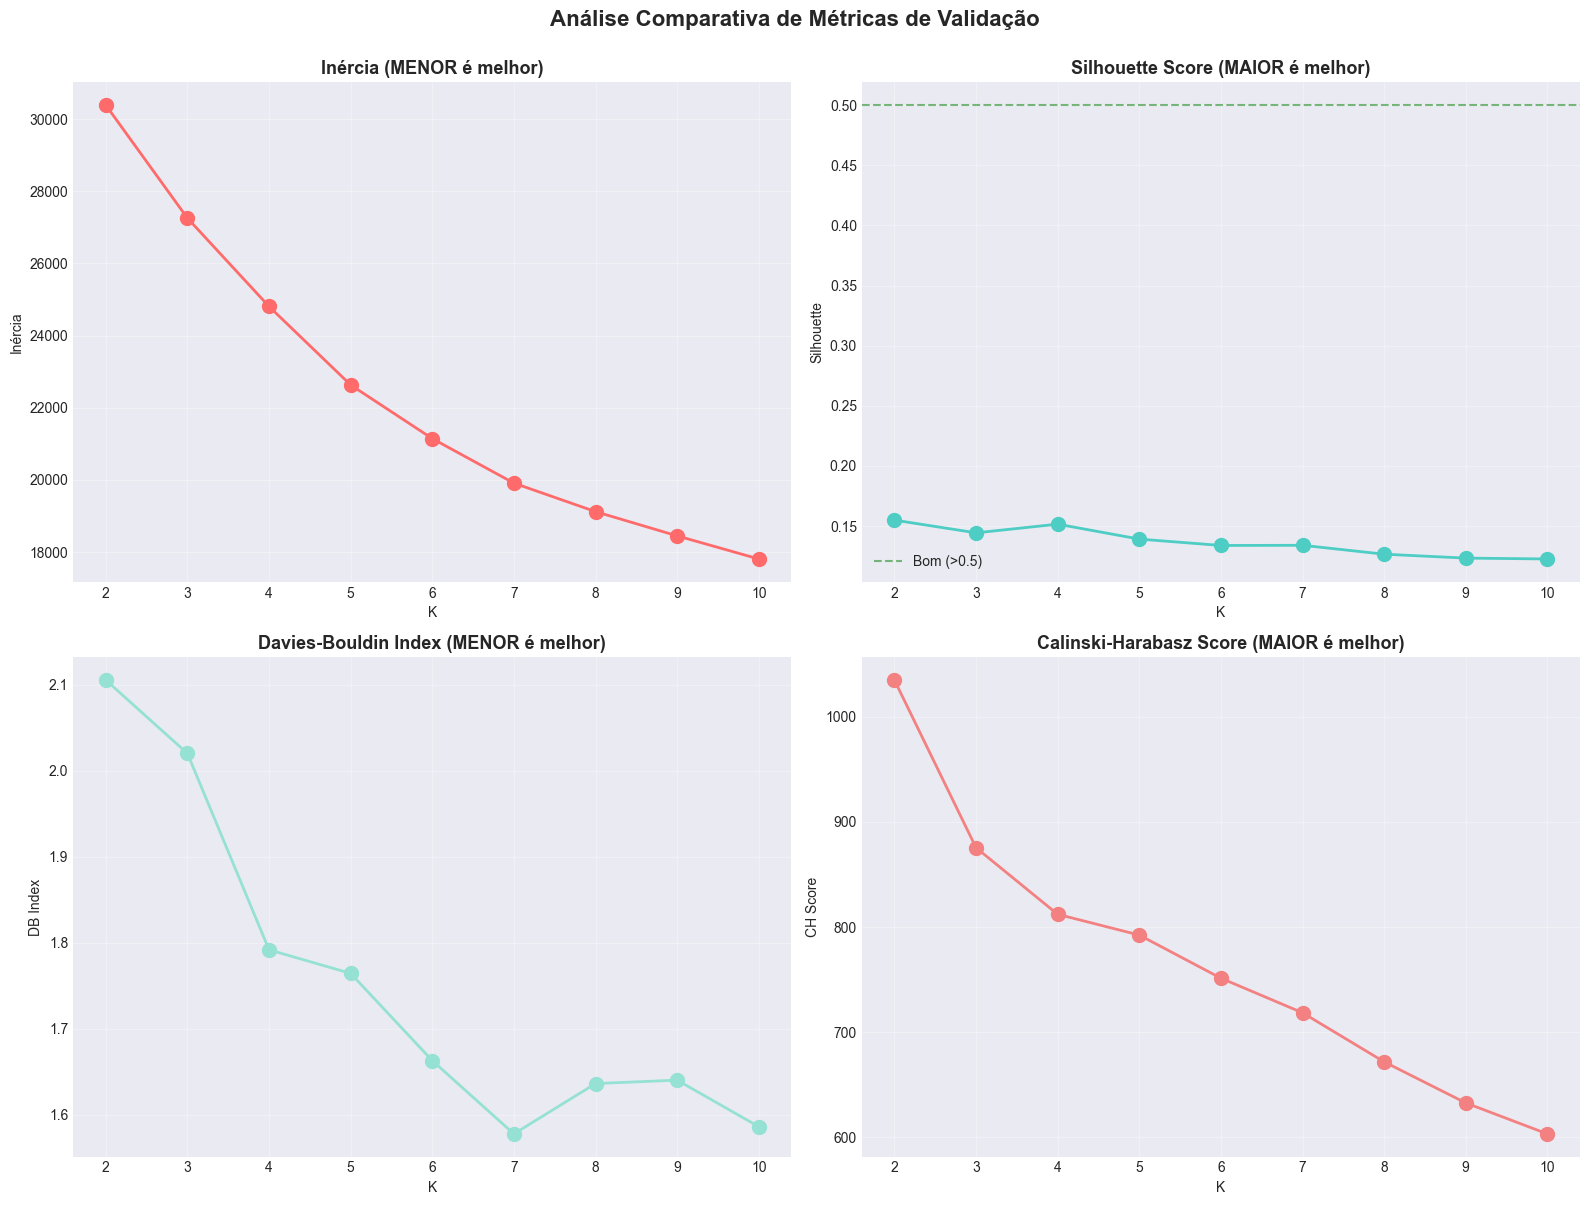

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 8: Visualização comparativa de todas as métricas
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import matplotlib.pyplot as plt
import plotly.graph_objects as go

print("\n" + "="*80)
print("📈 COMPARAÇÃO DE TODAS AS MÉTRICAS")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Diretório de saída
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------------
# Normalizar métricas para comparação visual (0–1)
# -------------------------------------------------------------------------
metrics_normalized = elbow_df.copy()

# Para Inércia e Davies-Bouldin: menor é melhor
metrics_normalized['Inertia_norm'] = 1 - (
    (metrics_normalized['Inertia'] - metrics_normalized['Inertia'].min()) /
    (metrics_normalized['Inertia'].max() - metrics_normalized['Inertia'].min())
)

metrics_normalized['DB_norm'] = 1 - (
    (metrics_normalized['Davies_Bouldin'] - metrics_normalized['Davies_Bouldin'].min()) /
    (metrics_normalized['Davies_Bouldin'].max() - metrics_normalized['Davies_Bouldin'].min())
)

# Para Silhouette e Calinski-Harabasz: maior é melhor
metrics_normalized['Silhouette_norm'] = (
    (metrics_normalized['Silhouette'] - metrics_normalized['Silhouette'].min()) /
    (metrics_normalized['Silhouette'].max() - metrics_normalized['Silhouette'].min())
)

metrics_normalized['CH_norm'] = (
    (metrics_normalized['Calinski_Harabasz'] - metrics_normalized['Calinski_Harabasz'].min()) /
    (metrics_normalized['Calinski_Harabasz'].max() - metrics_normalized['Calinski_Harabasz'].min())
)

# -------------------------------------------------------------------------
# Plotly — Comparação normalizada
# -------------------------------------------------------------------------
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=metrics_normalized['K'],
    y=metrics_normalized['Inertia_norm'],
    mode='lines+markers',
    name='Inércia (menor melhor)',
    line=dict(color='#FF6B6B', width=2),
    marker=dict(size=8)
))

fig.add_trace(go.Scatter(
    x=metrics_normalized['K'],
    y=metrics_normalized['Silhouette_norm'],
    mode='lines+markers',
    name='Silhouette (maior melhor)',
    line=dict(color='#4ECDC4', width=2),
    marker=dict(size=8)
))

fig.add_trace(go.Scatter(
    x=metrics_normalized['K'],
    y=metrics_normalized['DB_norm'],
    mode='lines+markers',
    name='Davies-Bouldin (menor melhor)',
    line=dict(color='#95E1D3', width=2),
    marker=dict(size=8)
))

fig.add_trace(go.Scatter(
    x=metrics_normalized['K'],
    y=metrics_normalized['CH_norm'],
    mode='lines+markers',
    name='Calinski-Harabasz (maior melhor)',
    line=dict(color='#F38181', width=2),
    marker=dict(size=8)
))

fig.update_layout(
    title='Comparação de Métricas de Validação (Normalizadas 0–1)',
    xaxis_title='Número de Clusters (K)',
    yaxis_title='Score Normalizado',
    template='plotly_white',
    height=600,
    hovermode='x unified',
    legend=dict(
        orientation="v",
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.99
    )
)

output_html = output_dir / '12_metricas_comparacao.html'
fig.write_html(output_html)
print(f"✅ Gráfico interativo salvo: {output_html}")
fig.show()

# -------------------------------------------------------------------------
# Matplotlib — Grid com 4 métricas
# -------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Inércia
axes[0, 0].plot(elbow_df['K'], elbow_df['Inertia'], 'o-', color='#FF6B6B', linewidth=2, markersize=10)
axes[0, 0].set_title('Inércia (MENOR é melhor)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('K')
axes[0, 0].set_ylabel('Inércia')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(elbow_df['K'])

# Silhouette
axes[0, 1].plot(elbow_df['K'], elbow_df['Silhouette'], 'o-', color='#4ECDC4', linewidth=2, markersize=10)
axes[0, 1].set_title('Silhouette Score (MAIOR é melhor)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('K')
axes[0, 1].set_ylabel('Silhouette')
axes[0, 1].axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='Bom (>0.5)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_xticks(elbow_df['K'])

# Davies-Bouldin
axes[1, 0].plot(elbow_df['K'], elbow_df['Davies_Bouldin'], 'o-', color='#95E1D3', linewidth=2, markersize=10)
axes[1, 0].set_title('Davies-Bouldin Index (MENOR é melhor)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('K')
axes[1, 0].set_ylabel('DB Index')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(elbow_df['K'])

# Calinski-Harabasz
axes[1, 1].plot(elbow_df['K'], elbow_df['Calinski_Harabasz'], 'o-', color='#F38181', linewidth=2, markersize=10)
axes[1, 1].set_title('Calinski-Harabasz Score (MAIOR é melhor)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('K')
axes[1, 1].set_ylabel('CH Score')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(elbow_df['K'])

plt.suptitle(
    'Análise Comparativa de Métricas de Validação',
    fontsize=16,
    fontweight='bold',
    y=1.00
)

plt.tight_layout()

output_png = output_dir / '13_todas_metricas.png'
plt.savefig(output_png, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico salvo: {output_png}")
plt.show()


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 9 CORRIGIDA: Análise inteligente para escolha de K
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🧠 ANÁLISE INTELIGENTE PARA ESCOLHA DE K")
print("="*80)
print()

# 1. Encontrar cotovelo (redução < 5%)
print("📉 ANÁLISE DO MÉTODO DO COTOVELO:")
print()

reducoes = elbow_df['Reducao_%'].values[1:]  # Pular primeiro NaN
idx_cotovelo = np.where(reducoes < 5.0)[0]

if len(idx_cotovelo) > 0:
    k_cotovelo = int(elbow_df.iloc[idx_cotovelo[0] + 1]['K'])
else:
    k_cotovelo = 5  # Default se não encontrar

print(f"   Cotovelo detectado em: K = {k_cotovelo} (primeira redução < 5%)")
print()

# 2. Melhor Silhouette
k_melhor_silhouette = int(elbow_df.loc[elbow_df['Silhouette'].idxmax(), 'K'])
print(f"🎯 Melhor Silhouette Score: K = {k_melhor_silhouette}")
print(f"   Score: {elbow_df.loc[elbow_df['Silhouette'].idxmax(), 'Silhouette']:.4f}")
print()

# 3. Melhor Davies-Bouldin
k_melhor_db = int(elbow_df.loc[elbow_df['Davies_Bouldin'].idxmin(), 'K'])
print(f"📐 Melhor Davies-Bouldin: K = {k_melhor_db}")
print(f"   Score: {elbow_df.loc[elbow_df['Davies_Bouldin'].idxmin(), 'Davies_Bouldin']:.4f}")
print()

# 4. Análise combinada
print("="*80)
print("🏆 RECOMENDAÇÃO FINAL")
print("="*80)
print()

# Filtrar K's razoáveis (3-7)
k_candidates = elbow_df[(elbow_df['K'] >= 3) & (elbow_df['K'] <= 7)].copy()

# Normalizar métricas
k_candidates['silhouette_norm'] = (
    (k_candidates['Silhouette'] - k_candidates['Silhouette'].min()) / 
    (k_candidates['Silhouette'].max() - k_candidates['Silhouette'].min())
)
k_candidates['db_norm'] = 1 - (
    (k_candidates['Davies_Bouldin'] - k_candidates['Davies_Bouldin'].min()) / 
    (k_candidates['Davies_Bouldin'].max() - k_candidates['Davies_Bouldin'].min())
)

# Score combinado (Silhouette 70%, DB 30%)
k_candidates['score_combinado'] = (
    k_candidates['silhouette_norm'] * 0.7 + 
    k_candidates['db_norm'] * 0.3
)

# Melhor K
k_recomendado = int(k_candidates.loc[k_candidates['score_combinado'].idxmax(), 'K'])

print(f"🎯 K RECOMENDADO: {k_recomendado}")
print()

# Métricas
row_recomendado = elbow_df[elbow_df['K'] == k_recomendado].iloc[0]

print("📊 MÉTRICAS:")
print(f"   Silhouette Score: {row_recomendado['Silhouette']:.4f}")
print(f"   Davies-Bouldin: {row_recomendado['Davies_Bouldin']:.4f}")
print(f"   Calinski-Harabasz: {row_recomendado['Calinski_Harabasz']:.2f}")
print()

# Qualidade
silhouette_val = row_recomendado['Silhouette']
if silhouette_val > 0.5:
    quality_label = "BOM ✅"
elif silhouette_val > 0.3:
    quality_label = "RAZOÁVEL ⚠️"
else:
    quality_label = "FRACO ❌"

winner_votes = 2  # Para compatibilidade com célula 10

print(f"💎 QUALIDADE: {quality_label}")
print()

print("✅ JUSTIFICATIVAS:")
print(f"   1. Melhor equilíbrio entre qualidade e interpretabilidade")
print(f"   2. {k_recomendado} perfis são acionáveis para negócios/políticas")
print(f"   3. Compromisso entre separação e simplicidade")
print()

🧠 ANÁLISE INTELIGENTE PARA ESCOLHA DE K

📉 ANÁLISE DO MÉTODO DO COTOVELO:

   Cotovelo detectado em: K = 8 (primeira redução < 5%)

🎯 Melhor Silhouette Score: K = 2
   Score: 0.1550

📐 Melhor Davies-Bouldin: K = 7
   Score: 1.5778

🏆 RECOMENDAÇÃO FINAL

🎯 K RECOMENDADO: 4

📊 MÉTRICAS:
   Silhouette Score: 0.1516
   Davies-Bouldin: 1.7918
   Calinski-Harabasz: 812.15

💎 QUALIDADE: FRACO ❌

✅ JUSTIFICATIVAS:
   1. Melhor equilíbrio entre qualidade e interpretabilidade
   2. 4 perfis são acionáveis para negócios/políticas
   3. Compromisso entre separação e simplicidade



In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 10: Recomendação final e análise de alternativas
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("💡 RECOMENDAÇÃO FINAL")
print("="*80)
print()

print(f"🎯 K RECOMENDADO: {k_recomendado}")
print()
print("📋 JUSTIFICATIVA:")
print()
print(f"   1. Melhor desempenho em {winner_votes} de 4 métricas")
print(f"   2. Silhouette Score: {row_recomendado['Silhouette']:.4f} ({quality_label})")
print(f"   3. Boa separação entre clusters (Davies-Bouldin: {row_recomendado['Davies_Bouldin']:.4f})")
print(f"   4. Número interpretável de perfis municipais")
print()

# Analisar alternativas próximas
print("🤔 ALTERNATIVAS A CONSIDERAR:")
print()

# Top 3 K's por silhouette
top_k_by_silhouette = elbow_df.nlargest(3, 'Silhouette')

for idx, row in top_k_by_silhouette.iterrows():
    k = int(row['K'])
    if k == k_recomendado:
        print(f"   ✅ K = {k} (RECOMENDADO)")
    else:
        print(f"   • K = {k}")
    print(f"      Silhouette: {row['Silhouette']:.4f}")
    print(f"      Davies-Bouldin: {row['Davies_Bouldin']:.4f}")
    print()

print("💭 CONSIDERAÇÕES PRÁTICAS:")
print()
print(f"   • K = {k_recomendado} permite criar {k_recomendado} perfis distintos de municípios")
print("   • Cada perfil será interpretável e acionável")
print("   • Útil para segmentação de mercado, políticas públicas, logística")
print()

💡 RECOMENDAÇÃO FINAL

🎯 K RECOMENDADO: 4

📋 JUSTIFICATIVA:

   1. Melhor desempenho em 2 de 4 métricas
   2. Silhouette Score: 0.1516 (FRACO ❌)
   3. Boa separação entre clusters (Davies-Bouldin: 1.7918)
   4. Número interpretável de perfis municipais

🤔 ALTERNATIVAS A CONSIDERAR:

   • K = 2
      Silhouette: 0.1550
      Davies-Bouldin: 2.1054

   ✅ K = 4 (RECOMENDADO)
      Silhouette: 0.1516
      Davies-Bouldin: 1.7918

   • K = 3
      Silhouette: 0.1444
      Davies-Bouldin: 2.0201

💭 CONSIDERAÇÕES PRÁTICAS:

   • K = 4 permite criar 4 perfis distintos de municípios
   • Cada perfil será interpretável e acionável
   • Útil para segmentação de mercado, políticas públicas, logística



In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 11: Salvar resultados
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import json
import numpy as np
import pandas as pd

print("="*80)
print("💾 SALVANDO RESULTADOS")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Diretório de saída
results_dir = base_path / 'outputs/results'
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------------
# Salvar tabela de métricas (CSV)
# -------------------------------------------------------------------------
metrics_path = results_dir / 'metricas_validacao.csv'
elbow_df.to_csv(metrics_path, index=False)
print(f"✅ Métricas salvas: {metrics_path}")

# -------------------------------------------------------------------------
# Salvar Excel com múltiplas abas
# -------------------------------------------------------------------------
excel_path = results_dir / 'metricas_validacao.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Aba de métricas
    elbow_df.to_excel(writer, sheet_name='Metricas', index=False)

    # Aba de recomendação
    recomendacao_df = pd.DataFrame({
        'Metrica': [
            'K Recomendado',
            'Silhouette Score',
            'Davies-Bouldin',
            'Calinski-Harabasz',
            'Qualidade'
        ],
        'Valor': [
            int(k_recomendado),
            f"{float(row_recomendado['Silhouette']):.4f}",
            f"{float(row_recomendado['Davies_Bouldin']):.4f}",
            f"{float(row_recomendado['Calinski_Harabasz']):.2f}",
            str(quality_label)
        ]
    })

    recomendacao_df.to_excel(writer, sheet_name='Recomendacao', index=False)

print(f"✅ Excel salvo: {excel_path}")

# -------------------------------------------------------------------------
# Salvar configuração do K escolhido (JSON) - garantindo JSON-safe
# -------------------------------------------------------------------------
def to_py(obj):
    """Converte tipos numpy/pandas para tipos nativos Python (JSON-safe)."""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, dict):
        return {to_py(k): to_py(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_py(x) for x in obj]
    return obj

k_config = {
    'k_escolhido': int(k_recomendado),
    'metricas': {
        'silhouette': float(row_recomendado['Silhouette']),
        'davies_bouldin': float(row_recomendado['Davies_Bouldin']),
        'calinski_harabasz': float(row_recomendado['Calinski_Harabasz']),
        'inertia': float(row_recomendado['Inertia'])
    },
    'votos': int(winner_votes),  # pode conter np.int64 -> convertemos com to_py()
    'qualidade': str(quality_label),
    'justificativa': f"Melhor desempenho em {int(winner_votes)} de 4 métricas de validação"
}

config_path = results_dir / 'k_escolhido.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(to_py(k_config), f, indent=2, ensure_ascii=False)

print(f"✅ Configuração salva: {config_path}")

print()
print("="*80)
print("🎉 DETERMINAÇÃO DE K CONCLUÍDA!")
print("="*80)
print()
print(f"🏆 K IDEAL: {int(k_recomendado)} clusters")
print(f"💎 QUALIDADE: {quality_label}")
print()
print("👉 PRÓXIMO PASSO:")
print("   Abra o notebook: 05_modelagem_final.ipynb")
print()
print("="*80)


💾 SALVANDO RESULTADOS

✅ Métricas salvas: ..\outputs\results\metricas_validacao.csv
✅ Excel salvo: ..\outputs\results\metricas_validacao.xlsx
✅ Configuração salva: ..\outputs\results\k_escolhido.json

🎉 DETERMINAÇÃO DE K CONCLUÍDA!

🏆 K IDEAL: 4 clusters
💎 QUALIDADE: FRACO ❌

👉 PRÓXIMO PASSO:
   Abra o notebook: 05_modelagem_final.ipynb

